In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../dataset/Twitter_Data.csv")
df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  str    
 1   category    162973 non-null  float64
dtypes: float64(1), str(1)
memory usage: 2.5 MB


In [4]:
df = df.dropna()
df.info()

<class 'pandas.DataFrame'>
Index: 162969 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162969 non-null  str    
 1   category    162969 non-null  float64
dtypes: float64(1), str(1)
memory usage: 3.7 MB


In [5]:
df["category"].value_counts()

category
 1.0    72249
 0.0    55211
-1.0    35509
Name: count, dtype: int64

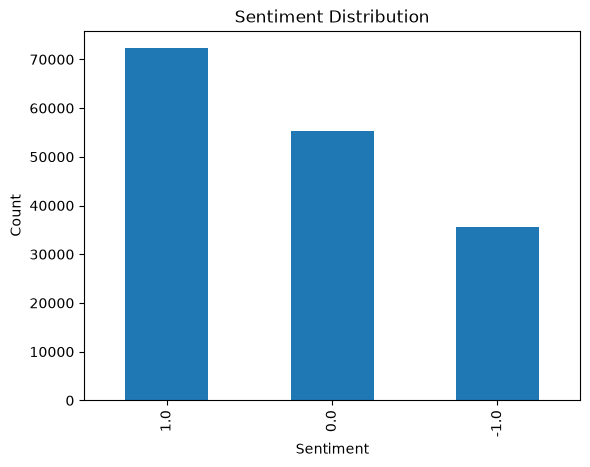

In [6]:
import matplotlib.pyplot as plt

df["category"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [7]:
df["clean_text"].head(10)

0    when modi promised “minimum government maximum...
1    talk all the nonsense and continue all the dra...
2    what did just say vote for modi  welcome bjp t...
3    asking his supporters prefix chowkidar their n...
4    answer who among these the most powerful world...
5             kiya tho refresh maarkefir comment karo 
6    surat women perform yagna seeks divine grace f...
7    this comes from cabinet which has scholars lik...
8    with upcoming election india saga going import...
9                           gandhi was gay does modi  
Name: clean_text, dtype: str

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
X = df["clean_text"]
y = df["category"]
print(X.head())
print(y.head())

0    when modi promised “minimum government maximum...
1    talk all the nonsense and continue all the dra...
2    what did just say vote for modi  welcome bjp t...
3    asking his supporters prefix chowkidar their n...
4    answer who among these the most powerful world...
Name: clean_text, dtype: str
0   -1.0
1    0.0
2    1.0
3    1.0
4    1.0
Name: category, dtype: float64


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X = tfidf.fit_transform(X)

print(X.shape)

(162969, 106924)


In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)

(130375, 106924)
(32594, 106924)


In [12]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [24]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# Create Model
nb_model = MultinomialNB()

# Train Model
nb_model.fit(X_train, y_train)

# Prediction
y_pred_nb = nb_model.predict(X_test)

# Accuracy
nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.5673436828864208


In [14]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9184512486960791


In [15]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

from sklearn.metrics import accuracy_score

print("Linear SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

Linear SVM Accuracy: 0.9432104068233417


In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

        -1.0       0.92      0.87      0.90      7152
         0.0       0.95      0.98      0.96     11067
         1.0       0.95      0.95      0.95     14375

    accuracy                           0.94     32594
   macro avg       0.94      0.93      0.94     32594
weighted avg       0.94      0.94      0.94     32594



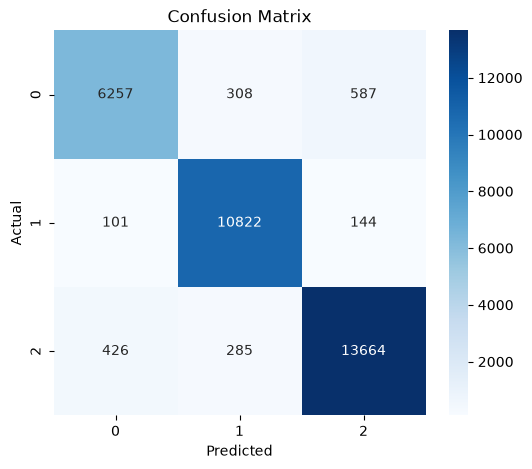

In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
import joblib

joblib.dump(svm_model, "../models/sentiment_model.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [22]:
text = input("Enter a sentence: ")

text_vector = tfidf.transform([text])

prediction = svm_model.predict(text_vector)

if prediction[0] == 1:
    print("😊 Positive")
elif prediction[0] == 0:
    print("😐 Neutral")
else:
    print("😡 Negative")
    

😐 Neutral


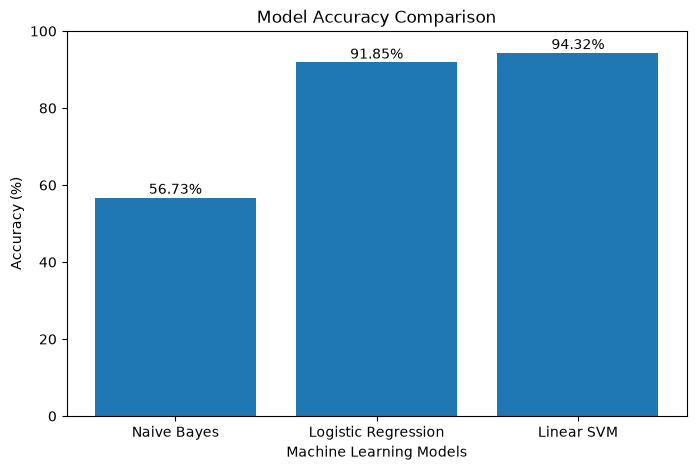

In [23]:
models = ["Naive Bayes", "Logistic Regression", "Linear SVM"]
accuracies = [56.73, 91.85, 94.32]

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f"{v:.2f}%", ha="center")

plt.show()